# Lab7: Optimizers

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

## Generating a Synthetic Dataset

In [2]:
np.random.seed(42)

X = np.random.rand(1000, 1)
y = 3 * X + 2 + np.random.randn(1000, 1) * 0.1

## Ploting the data

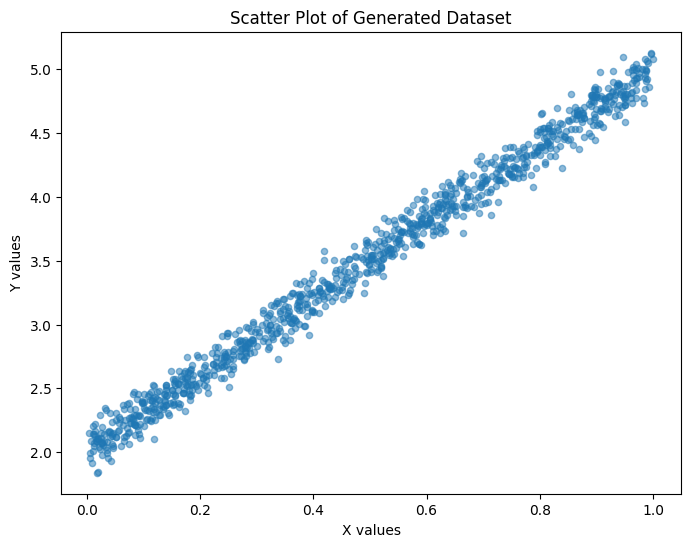

In [3]:
plt.figure(figsize=(8,6))

plt.scatter(X, y, s=20, alpha=0.5)

plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Scatter Plot of Generated Dataset")

plt.show()

## Model Traning Function

In [4]:
def train_model(batch_size, epochs=20, lr=0.01):

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(1, input_shape=(1,))
    ])

    loss_fn = tf.keras.losses.MeanSquaredError()

    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
        loss=loss_fn
    )

    history = model.fit(
        X, y,
        batch_size=batch_size,
        epochs=epochs, verbose=0
    )

    loss_history = history.history['loss']

    return loss_history

## Experiment 1: Batch Gradient Descent

In [5]:
bgd_loss = train_model(batch_size=len(X))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


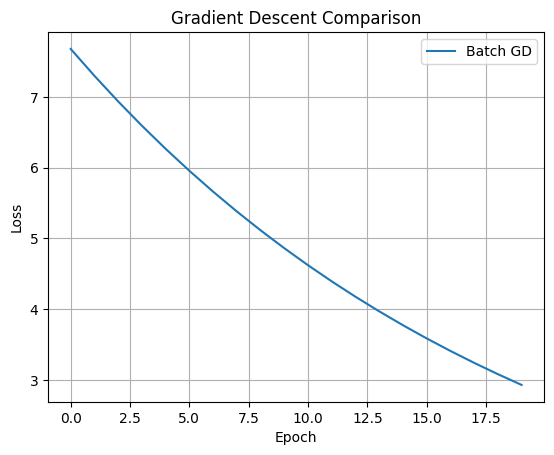

In [6]:
plt.plot(bgd_loss, label="Batch GD")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gradient Descent Comparison")
plt.legend()
plt.grid(True)

plt.show()

## Experiment 2: Stochastic Gradient Descent (SGD)


In [7]:
sgd_loss = train_model(batch_size=1)

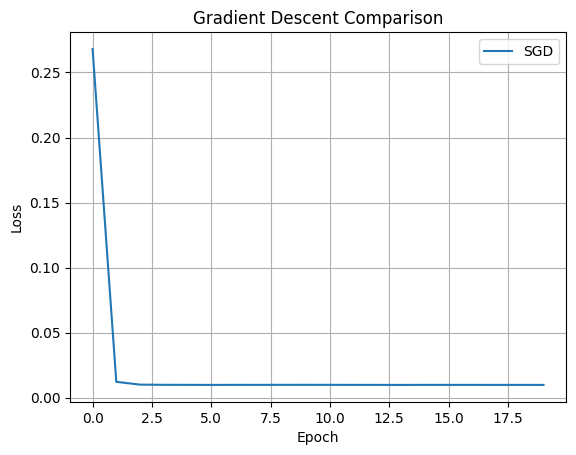

In [8]:
plt.plot(sgd_loss, label="SGD")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gradient Descent Comparison")
plt.legend()
plt.grid(True)

plt.show()

## Experiment 3: Mini-Batch Gradient Descent

In [9]:
mbgd_loss = train_model(batch_size=32)

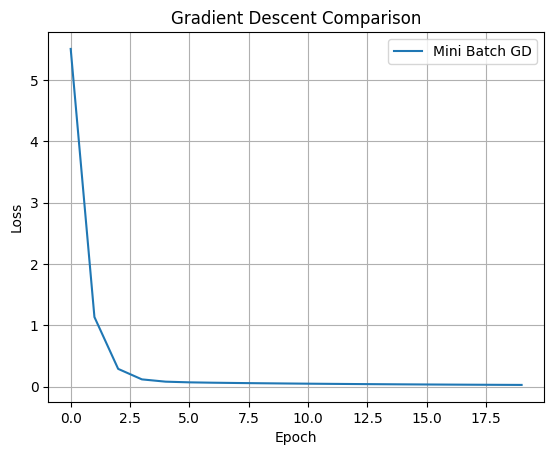

In [10]:
plt.plot(mbgd_loss, label="Mini Batch GD")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gradient Descent Comparison")
plt.legend()
plt.grid(True)

plt.show()

## Comparative Chart: ALL three methods

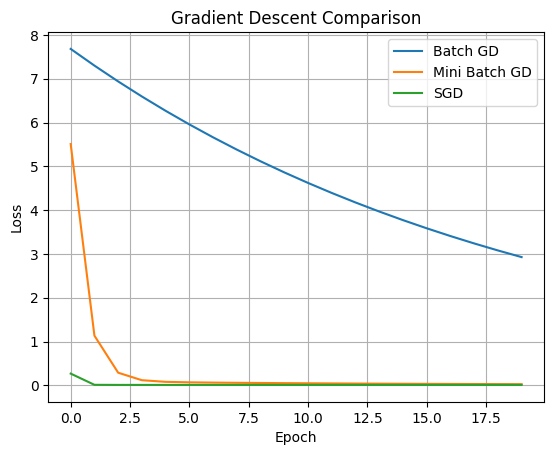

In [11]:
plt.plot(bgd_loss, label="Batch GD")
plt.plot(mbgd_loss, label="Mini Batch GD")
plt.plot(sgd_loss, label="SGD")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gradient Descent Comparison")
plt.legend()
plt.grid(True)

plt.show()

## Exercise 1: Effect of Learning Rate

### Objective:
To study the effect of learning rate on convergence behavior.

### Task:
Train the same model using Mini-Batch Gradient Descent - Use learning rates: 0.001, 0.01, and 0.1 - Plot loss vs epochs for each case


In [12]:
learning_rates = [0.001, 0.01, 0.1]

lr_histories = {}

for lr in learning_rates:
    lr_histories[lr] = train_model(batch_size=32, lr=lr)

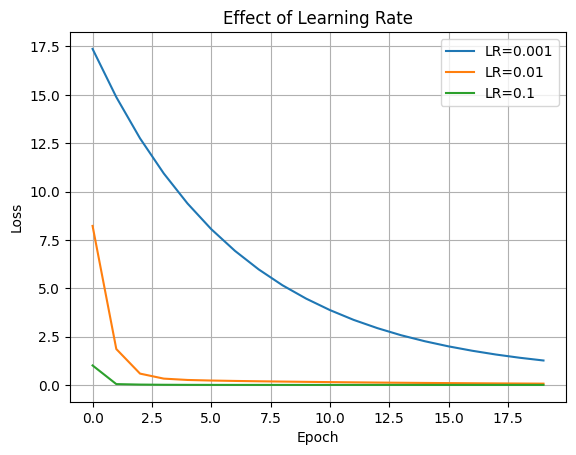

In [13]:
for lr in learning_rates:
    plt.plot(lr_histories[lr], label=f"LR={lr}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate")
plt.legend()
plt.grid(True)
plt.show()

Questions:

1. Which learning rate converges fastest?  
0.1 Learning Rate Converges Fastest.

2. Which learning rate causes instability?  
0.001 caluses instability because the loss is too high.

3. What happens if the learning rate is too small?  
the model doesn't converges in 5 epochs like other since gradient updates are too small it takes a long time to reach convergance.

## Exercise 2: Effect of Batch Size

### Objective:
To analyze how batch size influences training stability and speed.

### Task:
Train the model using batch sizes: 1, 16, 64, and full dataset - Observe loss behavior

In [14]:
batch_sizes = [1,16,64,len(X)]

batch_histories = {}

for bs in batch_sizes:
    batch_histories[bs] = train_model(batch_size=bs)

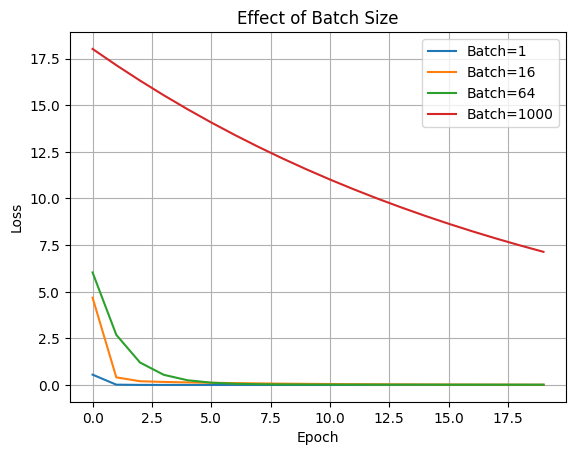

In [15]:
for bs in batch_sizes:
    plt.plot(batch_histories[bs], label=f"Batch={bs}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Batch Size")
plt.legend()
plt.grid(True)
plt.show()

Questions:

1. Which batch size behaves like SGD?  
Batch size 1 behaves like sgd.

2. Which batch size behaves like Batch Gradient Descent?  
1000 or len(x) batch size behaves like bgd.

3. Which batch size gives the best balance between speed and stability?  
16 gives a good balance between two.

### Knowledge Check

#### 1. Why does Batch Gradient Descent have a smooth loss curve but slow convergence?

Batch Gradient Descent computes gradients using the entire dataset before updating the model weights. Since it uses all the training samples, the gradient estimate is more accurate and consistent, which results in a smooth loss curve. However, it is slow because the model has to process the whole dataset before every weight update.

#### 2. What causes fluctuations in the loss function when using SGD?

In Stochastic Gradient Descent (SGD), the model updates its weights using only one training sample at a time. Because each sample produces a different gradient, the updates vary a lot. This causes the loss function to fluctuate during training.

#### 3. Why is Mini-Batch Gradient Descent preferred for training deep neural networks?

Mini-Batch Gradient Descent updates the model using small batches of data instead of the entire dataset or a single sample. This provides a balance between stability and speed. The loss curve is less noisy than SGD and it trains faster than Batch Gradient Descent, which makes it commonly used in deep learning.

#### 4. What happens if the batch size is increased to the full dataset?

If the batch size becomes equal to the entire dataset, Mini-Batch Gradient Descent effectively becomes Batch Gradient Descent. The model updates the weights only once per epoch, which leads to more stable but slower training.

#### 5. How does shuffling the dataset affect SGD and Mini-Batch GD?

Shuffling the dataset changes the order of the training samples in every epoch. This prevents the model from learning patterns caused by the data order and helps improve the stability of training and generalization.